<a href="https://colab.research.google.com/github/Alireza-gf/accident-analysis/blob/main/US_Accidents_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install kaggle

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d sobhanmoosavi/us-accidents

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:31<00:00, 21.5MB/s]



In [6]:
!unzip us-accidents.zip

Archive:  us-accidents.zip
  inflating: US_Accidents_March23.csv  


In [7]:
import cudf
cudf.__version__

'26.02.01'

In [8]:
import cudf
df = cudf.read_csv("/content/US_Accidents_March23.csv")

In [9]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype
---  ------                 -----
 0   ID                     object
 1   Source                 object
 2   Severity               int64
 3   Start_Time             object
 4   End_Time               object
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object
 11  Street                 object
 12  City                   object
 13  County                 object
 14  State                  object
 15  Zipcode                object
 16  Country                object
 17  Timezone               object
 18  Airport_Code           object
 19  Weather_Timestamp      object
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float64
 23  

In [10]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [11]:
cols_to_drop = [
    # IDs
    "ID",
    "Source",
    "Description",

    # location
    "Street",
    "Zipcode",
    "Country",
    "End_Lat",
    "End_Lng",
    "Airport_Code",

    # time redundant
    "Weather_Timestamp",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",
    "Timezone",
    "Weather_Timestamp",

    # very noisy
    "Wind_Chill(F)",
    "Turning_Loop"
]

df = df.drop(columns=cols_to_drop)

In [12]:
import numpy as np

lens = df["Start_Time"].str.len()

np.unique(lens.to_numpy(), return_counts=True)

(array([19, 26, 29], dtype=int32), array([6985228,   60844,  682322]))

In [13]:
df["Start_Time"] = cudf.to_datetime(df["Start_Time"].str[:19])
df["End_Time"] = cudf.to_datetime(df["End_Time"].str[:19])

In [14]:
df["Hour"] = df["Start_Time"].dt.hour
df["Weekday"] = df["Start_Time"].dt.weekday
df["Month"] = df["Start_Time"].dt.month
df["is_night"] = (df["Sunrise_Sunset"] == "Night").astype("int8")
df["is_weekend"] = (df["Weekday"] >= 5).astype("int8")

In [15]:
for col in ["Hour","Weekday","Month","is_night","is_weekend"]:
    df[col] = df[col].astype("int16")

In [16]:
df["Severity"] = df["Severity"].astype("int8")

In [17]:
for col in [
    "Temperature(F)", "Humidity(%)",
    "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)",
    "Precipitation(in)", "Distance(mi)",
    "Start_Lat", "Start_Lng"
]:
    df[col] = df[col].astype("float32")

In [29]:
for col in [
    "City", "State", "County",
    "Wind_Direction",
    "Weather_Condition", "Sunrise_Sunset"
]:
    df[col] = df[col].astype("category")

In [20]:
bool_cols = [
    "Amenity","Bump","Crossing","Give_Way","Junction",
    "No_Exit","Railway","Roundabout","Station","Stop",
    "Traffic_Calming","Traffic_Signal"
]

for col in bool_cols:
    df[col] = df[col].astype("int8")

In [21]:
df.isnull().sum()

Severity                   0
Start_Time                 0
End_Time                   0
Start_Lat                  0
Start_Lng                  0
Distance(mi)               0
City                     253
County                     0
State                      0
Temperature(F)        163853
Humidity(%)           174144
Pressure(in)          140679
Visibility(mi)        177098
Wind_Direction        175206
Wind_Speed(mph)       571233
Precipitation(in)    2203586
Weather_Condition     173459
Amenity                    0
Bump                       0
Crossing                   0
Give_Way                   0
Junction                   0
No_Exit                    0
Railway                    0
Roundabout                 0
Station                    0
Stop                       0
Traffic_Calming            0
Traffic_Signal             0
Sunrise_Sunset         23246
Hour                       0
Weekday                    0
Month                      0
is_night               23246
is_weekend    

In [22]:
df = df.dropna(subset=["City"])

In [23]:
df["Temperature(F)"] = df["Temperature(F)"].fillna(df["Temperature(F)"].median())
df["Humidity(%)"] = df["Humidity(%)"].fillna(df["Humidity(%)"].median())
df["Pressure(in)"] = df["Pressure(in)"].fillna(df["Pressure(in)"].median())
df["Visibility(mi)"] = df["Visibility(mi)"].fillna(df["Visibility(mi)"].median())
df["Wind_Speed(mph)"] = df["Wind_Speed(mph)"].fillna(df["Wind_Speed(mph)"].median())

In [38]:
df["is_night"] = df["Sunrise_Sunset"].map({"Day": 0, "Night": 1})
df["is_night"] = df["is_night"].fillna(df["is_night"].mode()[0])

In [26]:
df["Precipitation(in)"] = df["Precipitation(in)"].fillna(0)

In [36]:
df["Wind_Direction"] = df["Wind_Direction"].fillna(df["Wind_Direction"].mode()[0])
df["Weather_Condition"] = df["Weather_Condition"].fillna(df["Weather_Condition"].mode()[0])
df["Sunrise_Sunset"] = df["Sunrise_Sunset"].fillna(df["Sunrise_Sunset"].mode()[0])

In [39]:
df.isnull().sum()

Severity             0
Start_Time           0
End_Time             0
Start_Lat            0
Start_Lng            0
Distance(mi)         0
City                 0
County               0
State                0
Temperature(F)       0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Direction       0
Wind_Speed(mph)      0
Precipitation(in)    0
Weather_Condition    0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Sunrise_Sunset       0
Hour                 0
Weekday              0
Month                0
is_night             0
is_weekend           0
dtype: int64

تاثیر شب و روز روی

In [40]:
df.groupby("is_night")["Severity"].mean()

is_night
0    2.209427
1    2.219069
Name: Severity, dtype: float64

تاثیر ساعت

In [41]:
df.groupby("Hour")["Severity"].mean()

Hour
5     2.219328
0     2.218836
4     2.233914
2     2.205780
7     2.190156
6     2.209118
18    2.227931
17    2.210298
9     2.225901
15    2.201437
19    2.237117
16    2.205474
10    2.220120
1     2.188857
14    2.199891
3     2.229615
23    2.203847
12    2.216333
11    2.214191
22    2.240575
21    2.241959
20    2.247471
8     2.191280
13    2.207447
Name: Severity, dtype: float64

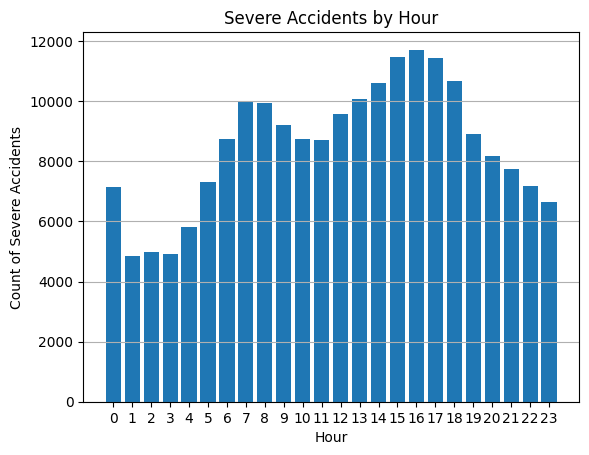

In [42]:
import matplotlib.pyplot as plt

temp = df[df["Severity"] == 4].groupby("Hour").size()

plt.bar(temp.index.to_pandas(), temp.to_pandas())

plt.title("Severe Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Count of Severe Accidents")
plt.xticks(range(0,24))
plt.grid(axis="y")

plt.show()

شرایط جاده

In [43]:
df.groupby("Traffic_Signal")["Severity"].mean()
df.groupby("Junction")["Severity"].mean()
df.groupby("Crossing")["Severity"].mean()

Crossing
0    2.231238
1    2.064457
Name: Severity, dtype: float64

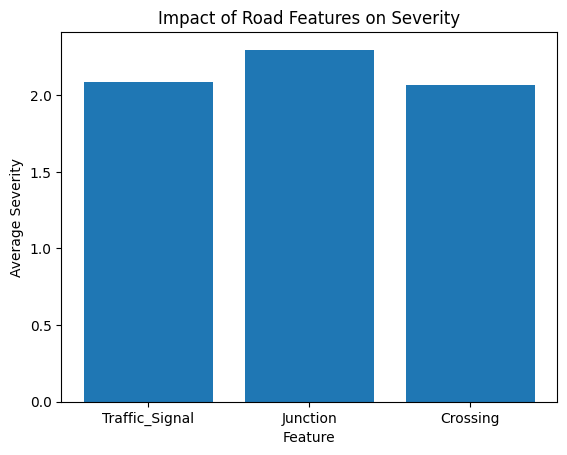

In [44]:
import matplotlib.pyplot as plt

features = ["Traffic_Signal", "Junction", "Crossing"]

values = [
    df.groupby("Traffic_Signal")["Severity"].mean()[1],
    df.groupby("Junction")["Severity"].mean()[1],
    df.groupby("Crossing")["Severity"].mean()[1]
]

plt.bar(features, values)

plt.title("Impact of Road Features on Severity")
plt.ylabel("Average Severity")
plt.xlabel("Feature")

plt.show()

مکان

In [45]:
df.groupby("State")["Severity"].mean().sort_values(ascending=False).head(10)

State
GA    2.506931
WI    2.473909
RI    2.458252
KY    2.454176
CO    2.443886
SD    2.442907
VT    2.425486
IA    2.419372
MO    2.399609
IN    2.397953
Name: Severity, dtype: float64

تاثیر آب‌وهوا

In [46]:
df.groupby("Weather_Condition")["Severity"].mean()

Weather_Condition
Light Snow Shower / Windy    2.000000
Partial Fog / Windy          3.000000
Light Snow Grains            2.500000
Light Snow and Sleet         2.200980
Squalls                      2.228571
                               ...   
Heavy Drizzle                2.347345
Light Freezing Drizzle       2.358065
Mostly Cloudy / Windy        2.179257
Heavy Freezing Drizzle       2.000000
Thunder in the Vicinity      2.157079
Name: Severity, Length: 144, dtype: float64

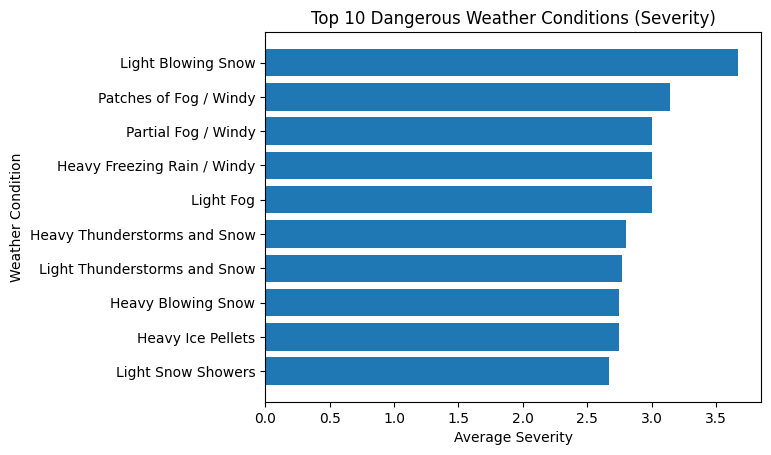

In [47]:
import matplotlib.pyplot as plt

weather = df.groupby("Weather_Condition")["Severity"].mean().sort_values(ascending=False).head(10)
plt.barh(weather.index.to_pandas(), weather.to_pandas())

plt.title("Top 10 Dangerous Weather Conditions (Severity)")
plt.xlabel("Average Severity")
plt.ylabel("Weather Condition")

plt.gca().invert_yaxis()
plt.show()

در شب و در هر نوع آب‌وهوا چند تا تصادف داریم

In [48]:
df.groupby(["is_night", "Weather_Condition"]).size()

is_night  Weather_Condition           
0         Sand / Dust Whirls Nearby             6
          Freezing Rain / Windy                16
1         Heavy Thunderstorms and Snow          2
0         Overcast                         259619
          T-Storm                           13508
                                           ...   
1         Heavy Freezing Drizzle                2
          Mist / Windy                          5
0         Snow and Sleet                      239
          Snow Showers                          1
          Fair                            1820650
Length: 255, dtype: int64